In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

In [2]:
# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner
from frank.utilities import convolve_profile

In [3]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d.frank2d import Frank2D 
from frank2d.geometry import Geometry
from frank2d.constants import rad_to_arcsec
from frank2d.plot import Plot
from frank2d.fitting import IterativeSolverMethod

In [4]:
from scipy.special import j0
from scipy.stats import binned_statistic

In [5]:
from scipy.optimize import curve_fit

### Load data

In [6]:
# UVtable
dir = "../../data/uvtable/"
data_file =  dir +"uvtable_SimulatedBlob.txt"


# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [7]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [8]:
geom_f2d = Geometry(inc, pa, dra, ddec)
geom_Ring = geom_f2d

In [9]:
Rmax = 3*rout
Qmax = max(np.hypot(u,v))
import math
N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

### Create the ring in uv-space

In [10]:
# Deprojection
du, dv, _ = geom_f2d.deproject(u, v)
dbaseline = np.hypot(du, dv)

baseline = np.hypot(u, v)

In [11]:
baseline_ring = baseline
u_ring = u
v_ring = v

In [12]:
Re_ring = np.median(Re[np.where(baseline_ring<5e4)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2.)*baseline_ring))

In [13]:
Imag_ring = np.zeros(len(Re))
Vis_ring = Re_ring + Imag_ring*1j

In [14]:
uvtable = {'u': u_ring, 'v': v_ring, 'vis': Vis_ring, 'weights': Weights}


### Frank2D

In [15]:
frank2d = Frank2D(N, Rmax)

In [16]:
frank2d.process_vis(uvtable)


===>  Setting gridded data...


In [17]:
PlotRing = Plot(frank2d, geom_Ring)

In [24]:
m = -1
p = -0.6
c = 10**(p -  5*m)
c

25118.864315095823

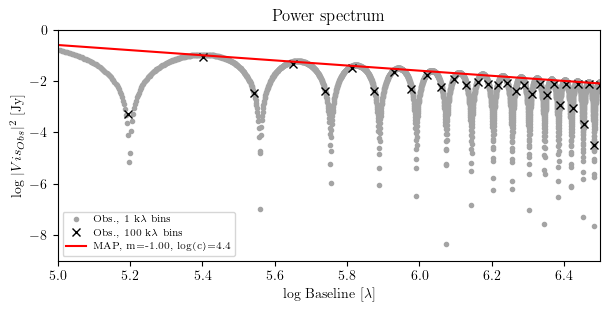

In [25]:
PlotRing.power_spectrum(uvtable, m = m, c =c)

### Best

In [26]:
frank2d.search_MAP(initial_guess={'m': m, 'p': p, 'logl': 4})

Using existing visibility data...
===>  Searching for MAP...
        + Initial guess:  {'m': -1, 'p': -0.6, 'logl': 4}
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 252.31 seconds
Setting the initial guess...
Optimizing the posterior...
 + Time to optimize the posterior: 1035.60 seconds


In [28]:
best = frank2d.MAP
best

{'m': -0.1528538394822414, 'c': 0.08538383164797039, 'l': 57270.47534124954}

### Run a new Frank2D Object

In [29]:
{'m': -0.1528538394822414, 'c': 0.08538383164797039, 'l': 57270.47534124954}

{'m': -0.1528538394822414, 'c': 0.08538383164797039, 'l': 57270.47534124954}

##### Run for different ls

In [30]:
#Ns = [ceil(0.5*N), ceil(N), ceil(1.25*N), ceil(1.5*N), ceil(1.75*N), ceil(2*N), ceil(2.5*N), ceil(3*N)]

In [46]:
best_N50_Rmax3 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
best_N100_Rmax3 = { 'm': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792 }

In [47]:
ls = [9e3, 1e4, 2e4, 4e4, 5e4, best_N50_Rmax3['l'], 8e4, 1e5]

In [60]:
ls = [best_N50_Rmax3['l']]

In [61]:
#ls = [best_N100_Rmax3['l']]

In [62]:
resolutions = []
resolutions_error = []

xxxxxxxxxxxxxxxxxxxxxx l =  56439.474897224536  xxxxxxxxxxxxxxxxxxxxxx


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -0.1528538394822414, 'c': 0.08538383164797039, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.06  min |  3.81 seconds
        +  Building system = 0.06  min |  3.88 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 260/50000 [00:46<2:28:21,  5.59 iterations/s]


            +  BiCGStab = 0.78  min |  46.56 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of s',
 'final_tol': 0.0884565253264863,
 'iterations': 260,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.24  min |  14.13 seconds
--> times building full visibility model = 0.24  min |  14.17 seconds


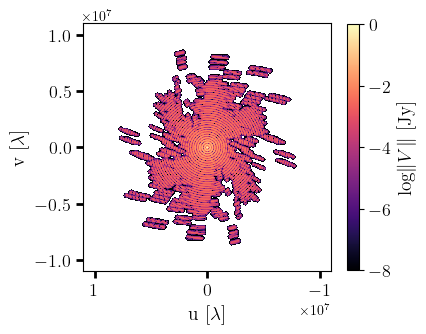

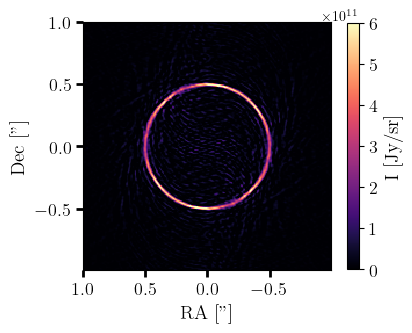

FWHM= 0.02160194698266532 +/- 9.911024414965879e-05 arcsec


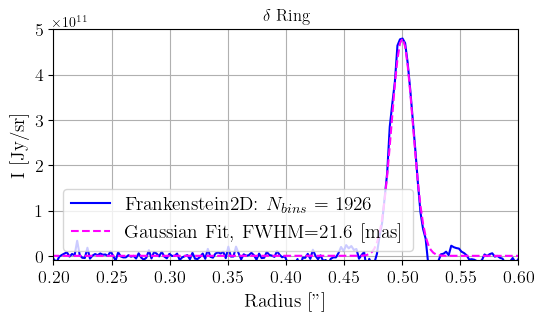

In [71]:
for l in ls:
    print("xxxxxxxxxxxxxxxxxxxxxx l = ", l, " xxxxxxxxxxxxxxxxxxxxxx")
    frank2d2 = Frank2D(N, Rmax)
    frank2d2.fit( data = uvtable, kernel_params = {'m': best['m'], 'c': best['c'], 'l':l}, rtol=1e-10, precond_type='jacobi')
    Plot_ = Plot(frank2d2, geom_f2d)
    Plot_.visibility(fig_size = 4,  title= r'', vmax= 0, vmin= -8)
    Plot_.intensity(fig_size = 4, zoom=3, gamma =1, title = '', vmax =0.6e12)

    def gauss(r, sigma):
        return np.exp(-0.5*((r-rout/2.)/sigma)**2)

    # FWHM
    # deproject
    x_model_1d, y_model_1d = geom_f2d.deproject_xy(Plot_._x_model_1d, Plot_._y_model_1d)
    x_model, y_model = Plot_._x_model, Plot_._y_model

    I = frank2d2.intensity_model

    r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
    bins_f2d = 3*N
    r = np.linspace(r_.min(), r_.max(), bins_f2d)
    edges = Plot_.edges(r)

    r_f2d, I_f2d = Plot_.get_profile(x_model, y_model, I, bins = edges)
    I_f2d = np.nan_to_num(I_f2d, nan=0)

    popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
    FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
    Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

    plt.close()
    plt.figure(figsize=(6,3))
    plt.plot(r_f2d, I_f2d, color='blue',label= r'Frankenstein2D: $N_{bins}$ = '+ str(bins_f2d))
    plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), ls = '--', color='magenta', label='Gaussian Fit, FWHM=%.1f [mas]'%(FWHM_frank2d*1000))
    plt.ylabel(r'I [Jy/sr]', size=14)
    plt.xlabel('Radius ["]', size=14)
    plt.tick_params(axis='both', which='both', labelsize=13)
    plt.xlim(0.2, 0.6)
    plt.grid()
    plt.ylim(-1e10, 0.5e12)

    plt.title(r'$\delta$ Ring ')
    plt.legend(loc='lower left', fontsize = 14)
    
    resolutions.append(FWHM_frank2d)
    resolutions_error.append(Error_FWHM_f2d)

    print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

In [45]:
ls

[9000.0,
 10000.0,
 20000.0,
 40000.0,
 50000.0,
 56439.474897224536,
 80000.0,
 100000.0]

In [53]:
custom_ticks = [9e3, 20000.0, 40000.0, 50000.0,  8e4, 1e5]

def format_sci(x):
    # 1. Crear el string base tipo "9.0e+03"
    s = f"{x:.0e}"
    # 2. Separar la base ("9.0") del exponente ("+03")
    base, exponent = s.split('e')
    # 3. Convertir exponente a entero para quitar el "+" y los ceros extra (ej. "+03" -> 3)
    return f"${base} \\times 10^{{{int(exponent)}}}$"

# Aplicar a la lista
custom_labels = [format_sci(x) for x in custom_ticks]

print(custom_labels)

['$9 \\times 10^{3}$', '$2 \\times 10^{4}$', '$4 \\times 10^{4}$', '$5 \\times 10^{4}$', '$8 \\times 10^{4}$', '$1 \\times 10^{5}$']


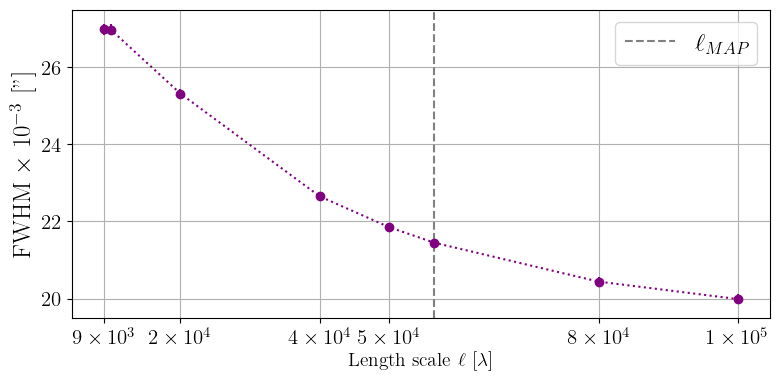

In [59]:
plt.figure(figsize=(9,4))
plt.errorbar(ls, np.array(resolutions)*1000, yerr=np.array(resolutions_error)*1000, fmt='o:', color='purple')
plt.xlabel(r'Length scale $\ell$ $[\lambda]$' , size =14)
plt.axvline(x=56439.474897224536, color='gray', linestyle='--', label='$\ell_{MAP}$')
plt.minorticks_off()
plt.ylabel(r'FWHM $\times$ $10^{-3}$ ["]', size =18)
#plt.xscale('log')
plt.xticks(custom_ticks, custom_labels)
plt.tick_params(axis='both', labelsize=15)
plt.legend(fontsize=18)
plt.grid()
plt.show()